In [3]:
from google.colab import drive
import pandas as pd

drive.mount('/content/drive')

data = pd.read_csv('/content/drive/MyDrive/dataset/card_transdata.csv')

data.head()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
0,57.877857,0.311140,1.945940,1.0,1.0,0.0,0.0,0.0
1,10.829943,0.175592,1.294219,1.0,0.0,0.0,0.0,0.0
2,5.091079,0.805153,0.427715,1.0,0.0,0.0,1.0,0.0
3,2.247564,5.600044,0.362663,1.0,1.0,0.0,1.0,0.0
4,44.190936,0.566486,2.222767,1.0,1.0,0.0,1.0,0.0


In [4]:
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Random Forest Classifier:

In [5]:

X = data.drop("fraud",axis=1)
y = data["fraud"]

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)
rf_classifier = RandomForestClassifier(random_state=42)
rf_classifier.fit(X_train,y_train)
new_transaction_features = data.sample(1).drop('fraud',axis=1)
print("\nRandomly sampled features for new transaction:")
print(new_transaction_features)
prediction = rf_classifier.predict(new_transaction_features)
print("\nPrediction for new transaction:")
print("Fraud" if prediction[0] == 1 else "Legitimate")

new_transaction_features1 = pd.DataFrame({
    'distance_from_home': [7],
    'distance_from_last_transaction': [3],
    'ratio_to_median_purchase_price': [0.1],
    'repeat_retailer': [0],
    'used_chip': [1],
    'used_pin_number': [0],
    'online_order': [0]
})
prediction = rf_classifier.predict(new_transaction_features1)
print("\nPrediction for new transaction:")
print("Fraud" if prediction[0] == 1 else "Legitimate")


Randomly sampled features for new transaction:
       distance_from_home  distance_from_last_transaction  \
69730           30.351663                        0.155037   

       ratio_to_median_purchase_price  repeat_retailer  used_chip  \
69730                        0.324251              1.0        1.0   

       used_pin_number  online_order  
69730              0.0           1.0  

Prediction for new transaction:
Legitimate

Prediction for new transaction:
Legitimate


# Feature Importance in random Forest Classifier:

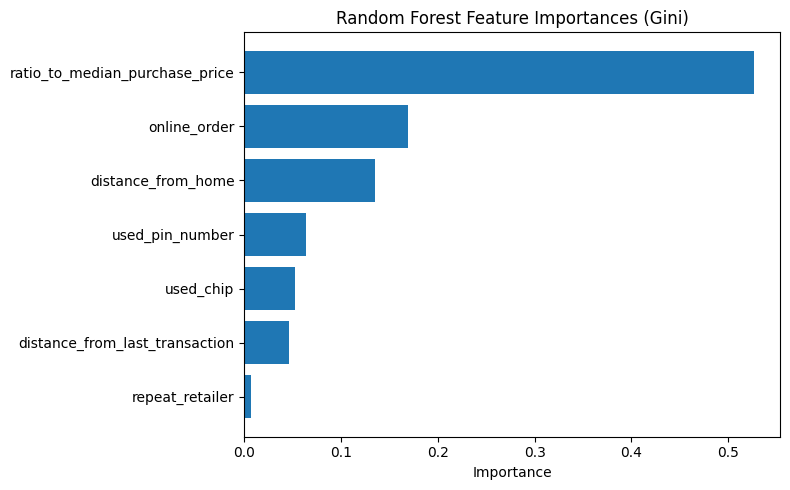

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Get importances
importances = rf_classifier.feature_importances_
feat_names = X_train.columns

# Sort descending
idx = np.argsort(importances)[::-1]
sorted_feats = feat_names[idx]
sorted_imps = importances[idx]

# Plot
plt.figure(figsize=(8,5))
plt.barh(sorted_feats, sorted_imps)
plt.gca().invert_yaxis()  # most important on top
plt.title("Random Forest Feature Importances (Gini)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


# Permutation Importance in Random Forest Classifier

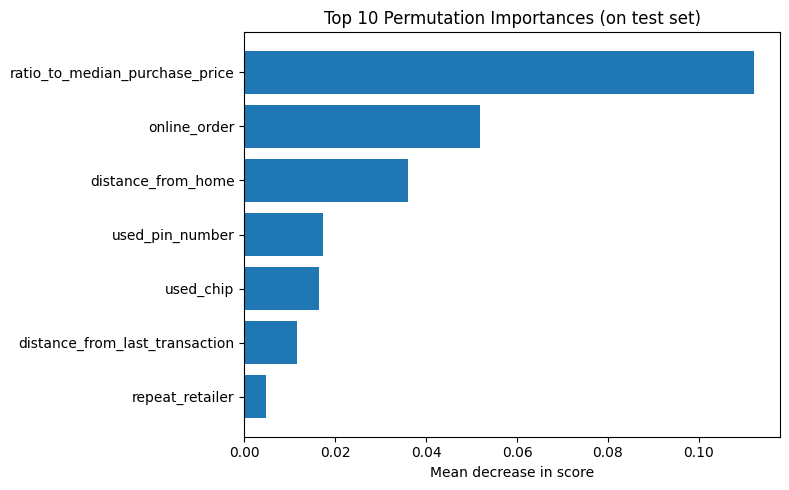

In [7]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    rf_classifier, X_test, y_test,
    n_repeats=10, random_state=42, n_jobs=-1
)

perm_imps = result.importances_mean
perm_idx = np.argsort(perm_imps)[::-1]

plt.figure(figsize=(8,5))
plt.barh(X_test.columns[perm_idx][:10], perm_imps[perm_idx][:10])
plt.gca().invert_yaxis()
plt.title("Top 10 Permutation Importances (on test set)")
plt.xlabel("Mean decrease in score")
plt.tight_layout()
plt.show()


# Logistic Regression:

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)
logreg_classifier = LogisticRegression(max_iter=1000, random_state=42)
logreg_classifier.fit(X_train_scaled,y_train)
new_transaction_features1 = pd.DataFrame({
    'distance_from_home': [89],
    'distance_from_last_transaction': [15],
    'ratio_to_median_purchase_price': [2.3],
    'repeat_retailer': [1],
    'used_chip': [0],
    'used_pin_number': [1],
    'online_order': [1]
})
prediction = logreg_classifier.predict(scaler.transform(new_transaction_features1))
print("\nPrediction for New Transaction:")
print("Fraud" if prediction[0] == 1 else "Legitimate")

y_pred = logreg_classifier.predict(X_test_scaled)
precision = precision_score(y_test,y_pred)
recall = recall_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)
accuracy = accuracy_score(y_test,y_pred)
print("\nEvaluation Metrics:")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"f1 score: {f1:.4f}")
print(f"accuracy: {accuracy:.4f}")


Prediction for New Transaction:
Legitimate

Evaluation Metrics:
Precision: 0.8902
Recall: 0.5974
f1 score: 0.7150
accuracy: 0.9585


# Logistic Regression feature importance = |coefficients|:

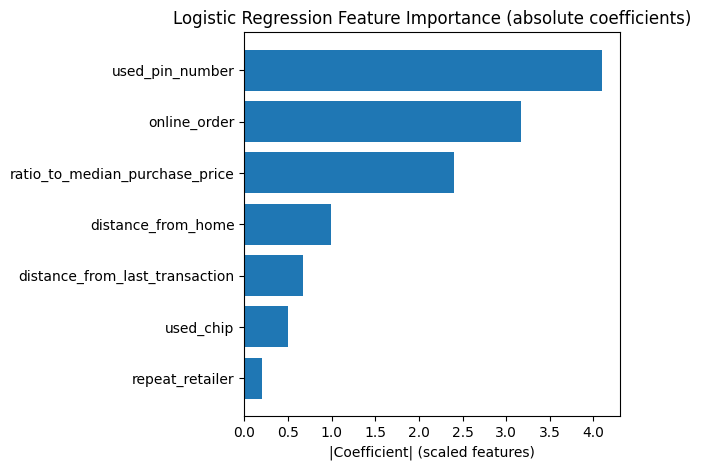

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


feature_names = X.columns  # if X is a DataFrame

coefs = logreg_classifier.coef_.ravel()  # shape: (n_features,)
importance = np.abs(coefs)

fi = pd.DataFrame({
    "feature": feature_names,
    "coef": coefs,
    "importance_abs": importance
}).sort_values("importance_abs", ascending=True)

plt.figure()
plt.barh(fi["feature"], fi["importance_abs"])
plt.xlabel("|Coefficient| (scaled features)")
plt.title("Logistic Regression Feature Importance (absolute coefficients)")
plt.tight_layout()
plt.show()
